**Role: the flagship, full-lifecycle tutorial.** One portfolio taken through every stage — calibrate, evaluate, invert, monitor, act, report — on the whole public surface. New to probcal? Start with the 20-minute [PD calibration walkthrough](../pd_calibration_walkthrough/) instead.

# PD calibration end to end: rare events, audit, recourse, monitoring

One credit-risk portfolio taken through the whole probcal 0.2.0 surface:
baseline GBM → reliability diagnosis → automatic calibrator selection with
bootstrap CIs → per-grade regulatory backtests → an auditable macro offset →
policy-threshold translation and a treecf counterfactual → anytime-valid
monitoring → JSON serialization of every artifact.

**Data.** The primary dataset is [Home Credit Default Risk
(2018)](https://www.kaggle.com/c/home-credit-default-risk) — ~307k
applications at an 8.1% event rate — downloaded through `kagglehub` under
*your* Kaggle credentials and cached locally (not redistributed). Without
kagglehub/credentials the notebook falls back to a documented synthetic
100k portfolio so it always executes (this is also what CI runs). A loader
stub for a genuinely rare (<3%) mortgage set (Freddie Mac single-family
loan-level data; registration required) is included at the end of this cell.


In [1]:
import numpy as np
import pandas as pd

from probcal import expit, logit

SEED = 42


def load_home_credit():
    """Home Credit application_train via kagglehub (user credentials, local cache)."""
    import kagglehub

    root = kagglehub.competition_download("home-credit-default-risk")
    df = pd.read_csv(f"{root}/application_train.csv")
    cols = [
        "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3", "AMT_CREDIT",
        "AMT_INCOME_TOTAL", "AMT_ANNUITY", "DAYS_BIRTH", "DAYS_EMPLOYED",
        "DAYS_ID_PUBLISH", "CNT_CHILDREN",
    ]
    X = df[cols].fillna(-999.0).to_numpy(float)
    y = df["TARGET"].to_numpy(float)
    return X, y, "Home Credit Default Risk (application_train, 10 features)"


def load_freddie_mac_stub():
    """Loader stub for the Freddie Mac single-family loan-level dataset (<3% event
    rate). Registration is required at freddiemac.com/research/datasets; point
    this at the downloaded origination + performance files and build a
    default-within-24-months target. Left as an exercise on purpose — the
    license does not permit redistribution."""
    raise NotImplementedError


def make_synthetic(n=100_000):
    """The documented fallback: a synthetic feature portfolio with a
    mildly non-linear true PD, so the GBM ranks well but mis-calibrates in the
    tail — the regime the rest of the notebook is about."""
    rng = np.random.default_rng(7)
    X = np.column_stack([
        rng.normal(size=n),
        rng.normal(size=n),
        rng.uniform(0.0, 1.0, n),
        rng.exponential(1.0, n),
        rng.integers(0, 6, n).astype(float),
    ])
    z = (
        1.1 * X[:, 0] - 0.8 * X[:, 1] + 2.2 * (X[:, 2] - 0.5) ** 2
        + 0.4 * np.log1p(X[:, 3]) + 0.15 * X[:, 4] - 4.1
    )
    y = (rng.random(n) < expit(z)).astype(float)
    return X, y, f"synthetic fallback portfolio (n={n:,})"


try:
    X, y, source = load_home_credit()
except Exception as exc:  # no kagglehub / no credentials -> the CI path
    print(f"falling back to synthetic data ({type(exc).__name__})")
    X, y, source = make_synthetic()

rng = np.random.default_rng(SEED)
order = rng.permutation(len(y))
X, y = X[order], y[order]
n = len(y)
i_train, i_cal = int(0.5 * n), int(0.75 * n)
X_train, y_train = X[:i_train], y[:i_train]
X_cal, y_cal = X[i_train:i_cal], y[i_train:i_cal]
X_test, y_test = X[i_cal:], y[i_cal:]
print(f"{source}: n={n:,}, event rate {y.mean():.2%}")


falling back to synthetic data (ModuleNotFoundError)
synthetic fallback portfolio (n=100,000): n=100,000, event rate 7.16%


## 1. A GBM baseline that ranks well

Nothing wrong with the model as a *ranker* — the trouble only shows once we
read its outputs as probabilities.


In [2]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score

# subsample left at 1.0 so the recourse section also runs correctly under
# treecf < 0.2.3, which routed split boundaries in float64 while sklearn
# casts inputs to float32 (fixed in treecf#21; guide/treecf.md T4)
model = GradientBoostingClassifier(
    n_estimators=120, max_depth=3, random_state=0
).fit(X_train, y_train)

s_cal = model.predict_proba(X_cal)[:, 1]
s_test = model.predict_proba(X_test)[:, 1]

pd.DataFrame(
    {
        "split": ["calibration", "test"],
        "n": [len(y_cal), len(y_test)],
        "event rate": [f"{y_cal.mean():.2%}", f"{y_test.mean():.2%}"],
        "mean score": [f"{s_cal.mean():.2%}", f"{s_test.mean():.2%}"],
        "AUC": [
            round(float(roc_auc_score(y_cal, s_cal)), 4),
            round(float(roc_auc_score(y_test, s_test)), 4),
        ],
    }
)


,split,n,event rate,mean score,AUC
0,calibration,25000,7.06%,7.11%,0.8156
1,test,25000,7.33%,7.17%,0.8250


## 2. Reliability: miscalibrated exactly where the policy lives

A 2% PD cut-off sits in the left tail — precisely where the smoothed
reliability curve and the calibration belt pull away from the diagonal.
Logit-scaled axes make the low-PD region readable; linear axes would hide it.


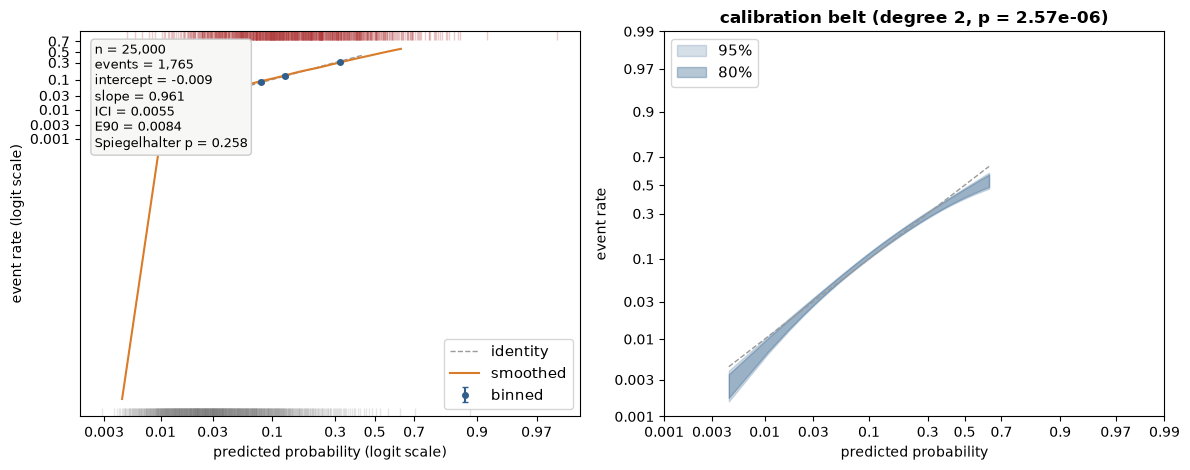

In [3]:
import matplotlib.pyplot as plt

from probcal import calibration_belt, reliability_binned, reliability_loess
from probcal.plots import plot_belt, plot_reliability

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
plot_reliability(
    reliability_binned(y_cal, s_cal),
    smooth=reliability_loess(y_cal, s_cal),
    scale="logit",
    y=y_cal,
    p=s_cal,
    ax=axes[0],
)
plot_belt(calibration_belt(y_cal, s_cal), scale="logit", ax=axes[1])
fig.tight_layout()


## 3. Automatic selection, with confidence intervals

`CalibratorSelector` runs the default menu under nested cross-validation.
On rare events, isotonic regression pays for its plateaus (few events per
block → coarse, high-variance steps in the tail); parametric families keep
sharing strength across the range, and the three-parameter `abm` beta can
bend the two tails separately when the distortion is asymmetric (as it
typically is on heavy real portfolios like Home Credit — on this synthetic
fallback a simpler map may win the log-loss criterion). `evaluate` puts
bootstrap CIs behind the comparison so the choice is not a point-estimate
coin flip.


In [4]:
from probcal import BetaCalibrator, CalibratorSelector, IsotonicCalibrator
from probcal.metrics import evaluate

selector = CalibratorSelector().fit(s_cal, y_cal)
print(selector.report_)
print(f"\nselected: {selector.best_name_}")


SelectionReport (criterion: log_loss)
method           log_loss  sd          guardrails  chosen  mcb          dsc      
---------------  --------  ----------  ----------  ------  -----------  ---------
beta_abm         0.207236  0.00750367  True                0.00153484   0.0494866
temperature      0.207393  0.00728911  True        *       0.00191271   0.0497076
platt            0.207436  0.00707666  True                0.00197495   0.0497267
ivap             0.207511  0.00750982  True                0.00120622   0.0488832
isotonic         0.209423  0.00947921  True                0.00302401   0.0487894
cir              0.20954   0.00936933  True                0.00334176   0.0489901
scaling_binning  0.210305  0.0068032   True                0.000539389  0.0454226
histogram_mass   0.210359  0.00763775  True                0.000380498  0.0452094

selected: temperature


In [5]:
rows = []
for name, proto in (("beta_abm", BetaCalibrator()), ("isotonic", IsotonicCalibrator())):
    cal_fit = type(proto)(**proto.get_params()).fit(s_cal, y_cal)
    rep = evaluate(
        y_test, cal_fit.predict_proba(s_test), n_boot=200,
        metrics=("log_loss", "brier", "smooth_ece"),
    )
    stats = zip(rep.names, rep.values, rep.ci_low, rep.ci_high, strict=True)
    for m, v, lo, hi in stats:
        rows.append({"calibrator": name, "metric": m, "estimate": round(float(v), 5),
                     "ci": (round(float(lo), 5), round(float(hi), 5))})
pd.DataFrame(rows)


,calibrator,metric,estimate,ci
0,beta_abm,log_loss,0.20909,"(0.20537, 0.21243)"
1,beta_abm,brier,0.05811,"(0.0571, 0.059)"
2,beta_abm,smooth_ece,0.01350,"(0.01545, 0.01771)"
3,isotonic,log_loss,0.20906,"(0.20521, 0.21229)"
4,isotonic,brier,0.05817,"(0.05715, 0.05908)"
5,isotonic,smooth_ece,0.00666,"(0.0, 0.01081)"


## 4. Per-grade regulatory backtest, before and after

The Jeffreys test (ECB IRB validation instructions) per grade: a small value
flags a grade whose assigned PD is likely understated. Grades here are fixed
PD bands on the calibrated scale.


In [6]:
from probcal.metrics import jeffreys_grade_test

cal = BetaCalibrator().fit(s_cal, y_cal)
p_test = cal.predict_proba(s_test)

edges = np.array([0.0, 0.005, 0.01, 0.02, 0.04, 0.08, 1.0])
labels = np.array(["A", "B", "C", "D", "E", "F"])
grades_before = labels[np.clip(np.searchsorted(edges, s_test, side="right") - 1, 0, 5)]
grades_after = labels[np.clip(np.searchsorted(edges, p_test, side="right") - 1, 0, 5)]

print("before calibration (grading on raw scores):")
print(jeffreys_grade_test(y_test, s_test, grades_before))
print("\nafter calibration (grading on calibrated PD):")
print(jeffreys_grade_test(y_test, p_test, grades_after))


before calibration (grading on raw scores):
JeffreysGradeResult(grades=('A', 'B', 'C', 'D', 'E', 'F'), n=array([ 359, 2313, 5072, 6282, 4761, 6213]), k=array([   0,    6,   56,  184,  314, 1272]), pd=array([0.00440324, 0.007683  , 0.01480762, 0.02862402, 0.05686274,
       0.20087443]), p_value=array([0.92503029, 0.99932446, 0.98942887, 0.37174313, 0.00398035,
       0.22354984]), light=('green', 'green', 'green', 'green', 'red', 'green'), ci_low=array([5.47269110e-06, 1.27434521e-03, 8.82845302e-03, 2.59490394e-02,
       6.02297728e-02, 1.96414155e-01]), ci_high=array([0.00533223, 0.00482805, 0.01366529, 0.03295118, 0.07206481,
       0.21325295]))

after calibration (grading on calibrated PD):
JeffreysGradeResult(grades=('A', 'B', 'C', 'D', 'E', 'F'), n=array([ 726, 2597, 4842, 5793, 4540, 6502]), k=array([   0,   14,   56,  169,  296, 1297]), pd=array([0.0040642 , 0.00761891, 0.01475023, 0.02861591, 0.05705508,
       0.19387104]), p_value=array([0.9849899 , 0.90966928, 0.97062401,

## 5. A macro shift, handled as an auditable offset

Mid-cycle, the through-the-cycle central tendency moves. The answer is not a
silent refit: `LogitOffset` applies one uniform log-odds shift, solved
against the target mean, and `audit_report` shows a validator the before and
after in one table. Ranking is untouched.


In [7]:
from probcal import LogitOffset

target_mean = float(1.25 * p_test.mean())  # the new central tendency
offset = LogitOffset(target_mean=target_mean).fit(p_test)
print(offset.audit_report(y_test, p_test))


AuditReport(delta=+0.2843, odds factor 1.3288, fitted 2026-08-30T07:49:29+00:00)
  portfolio mean: 0.07118 -> 0.08898
  slope:          +1.031 -> +1.031
  intercept:      +0.036 -> -0.248
  spiegelhalter p 0.308 -> 0.000
  guardrails ok:  True -> False


## 6. From policy to raw threshold — and to a counterfactual

"Approve below 2% calibrated PD" must reach production as a raw-score rule,
and reach the declined applicant as recourse. `interval_inverse` gives the
exact raw threshold (through the offset too, via `Chain`); treecf turns the
same calibrated target into the smallest feature change — with the exact
backend, a certificate.


In [8]:
from probcal import Chain

chain = Chain([cal, offset])  # post-offset policy: invert offset ∘ calibrator
lo_z, hi_z = chain.interval_inverse(0.0, 0.02, space="logit")
raw_cut = float(expit(np.array([hi_z]))[0])
print(f"'calibrated PD <= 2%' == raw model score <= {raw_cut:.4%} (logit {hi_z:+.3f})")


'calibrated PD <= 2%' == raw model score <= 1.6259% (logit -4.103)


In [9]:
try:
    from treecf import Explainer, Target

    p_chain = chain.predict_proba(s_test)
    declined = int(np.argmin(np.abs(p_chain - 0.05)))  # a borderline decline
    x0 = X_test[declined]
    exp = Explainer(model=model, background=X_train[:500])
    res = exp.explain(
        x0, target=Target.calibrated(chain, op="<=", value=0.02),
        seed=0, backend="exact",
    )
    if hasattr(res, "x_cf"):
        p_new = chain.predict_proba(model.predict_proba(np.asarray(res.x_cf)[None])[:, 1])
        print(f"proof: {res.proof}; changes: {res.changes}")
        print(f"calibrated PD {p_chain[declined]:.3%} -> {p_new[0]:.3%} (target <= 2%)")
    else:
        print(f"certified infeasible for this applicant: {res}")
except ImportError:
    print("treecf not installed — skipping the recourse demo "
          "(pip install 'probcal[treecf]')")


proof: heuristic; changes: {'f0': (0.2917438664638918, 0.2674443572759628), 'f1': (0.4586801565174143, 1.2076879739761353), 'f3': (0.750817657243643, 0.7452247440814972)}
calibrated PD 5.000% -> 1.974% (target <= 2%)


/tmp/ipykernel_358179/124215410.py:8: TreecfWarning: exact search exhausted its budget after 2,000,000 nodes; the result is the best found, not proven optimal; raise node_budget/time_budget_s or set gap= to accept a proven tolerance.
  res = exp.explain(


## 7. Monitoring: an e-process that survives being looked at monthly

Monthly cohorts replay through `CalibrationMonitor`. This dataset has no
time axis, so the replay is simulated the same way the monitor verification
simulation does it: for the stable months, outcomes are drawn from the calibrated
forecast itself (calibrated by construction); from month 14, from the
forecast shifted by +0.5 log-odds — a sustained macro deterioration. The
alarm rule "wealth ≥ 1/α" keeps its type-I guarantee at *every* look — no
correction for repeated testing — and after the alarm the report says
whether a re-offset is enough. Theory: the *Monitoring* chapter.


alarm at: m16; recommendation: re-offset
 - alarm at 'm16'; trailing-window offset +0.501 log-odds
 - shape e-process 9.46e+36 vs 1/alpha = 20.0 (reported; fires under level drift too, so not decisive alone)
 - trailing-window Cox slope 95% bootstrap CI [0.939, 1.025] contains 1
 - Cox-vs-offset residual LR on the trailing window 0.40 is within the chi-square(1) 5% bound 3.84
 - estimated drift onset at m15 (backward-CUSUM argmax of the plug-in log-LR increments — an estimate, not a test)
 - the recommendation is a diagnostic, not a test — see the monitoring chapter


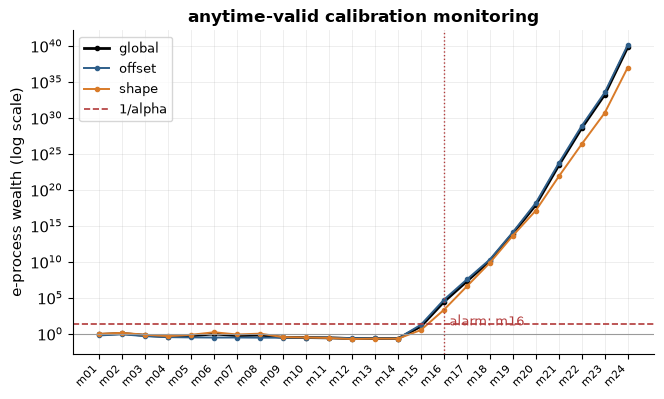

In [10]:
from probcal.monitor import CalibrationMonitor
from probcal.plots import plot_e_process

mon = CalibrationMonitor(alpha=0.05)
rng_m = np.random.default_rng(11)
pool = np.arange(len(y_test))
for month in range(24):
    take = rng_m.choice(pool, size=2000, replace=True)
    p_month = p_test[take]
    true_pd = p_month if month < 13 else expit(logit(p_month) + 0.5)
    y_month = (rng_m.random(2000) < true_pd).astype(float)
    step = mon.update(y_month, p_month, label=f"m{month + 1:02d}")

rep = mon.report()
print(f"alarm at: {rep.alarm_at}; recommendation: {rep.recommendation}")
for line in rep.reasoning:
    print(" -", line)
plot_e_process(rep)
plt.show()


## 8. Everything to JSON, and back

Every fitted artifact serializes to versioned, human-readable JSON — never
pickle — and reloads bit-for-bit. Fingerprints (version- and
timestamp-blind) name each artifact for registries, monitors, and recourse
certificates.


In [11]:
import json

from probcal import BaseCalibrator

artifacts = {
    "calibrator.json": cal,
    "offset.json": offset,
    "chain.json": chain,
    "monitor.json": mon,
}
for fname, obj in artifacts.items():
    text = obj.to_json()
    loaded = type(obj).from_json(text)
    same = np.array_equal(
        obj.predict_proba(s_test[:100]) if hasattr(obj, "predict_proba") else 1,
        loaded.predict_proba(s_test[:100]) if hasattr(loaded, "predict_proba") else 1,
    )
    print(f"{fname:16s} {len(text):>8,} bytes  fingerprint {obj.fingerprint()[:16]}…  "
          f"round-trip bit-identical: {bool(same)}")

# registry dispatch: the class need not be known in advance
obj = BaseCalibrator.from_dict(json.loads(cal.to_json()))
print(f"\nregistry loaded a {type(obj).__name__} — schema 1, readable by every 0.x release")


calibrator.json       617 bytes  fingerprint c428094cb67d501a…  round-trip bit-identical: True
offset.json           542 bytes  fingerprint 248fa5d37781b08d…  round-trip bit-identical: True
chain.json          1,587 bytes  fingerprint bc18ecf74caf3bec…  round-trip bit-identical: True


monitor.json     2,639,938 bytes  fingerprint 04674e277f45c86a…  round-trip bit-identical: True

registry loaded a BetaCalibrator — schema 1, readable by every 0.x release


## 9. Conservative margins: most-prudent PDs and margin-of-conservatism

Two more decision-relevant readings sit alongside calibration. Pluto & Tasche's most-prudent
PD gives a defensible upper bound for a grade even when it saw few or no defaults, by pooling
it with every worse grade under the rating-monotonicity assumption. Margin-of-conservatism
(MoC) offsets do a different job: they *compose* with an existing calibrator — never replace
it — re-anchoring an already-calibrated portfolio's mean at a conservative reading of realized
outcomes. Theory: the *Conservatism* chapter.


In [12]:
from probcal.metrics import pluto_tasche_from_arrays

pt = pluto_tasche_from_arrays(
    grades_after, y_test, order=("A", "B", "C", "D", "E", "F"), confidence=0.9,
)
print(pt.interpret())


Interpretation[PlutoTasche]
parameter   value    
----------  ---------
pd_upper.A  0.0754369
pd_upper.B  0.0776904
pd_upper.C  0.0863313
pd_upper.D  0.10775  
pd_upper.E  0.148644 
pd_upper.F  0.205972 
- grade A: 0 defaults among 726 obligors; pooled with worse grades (n*=25000, d*=1832); most-prudent PD at 90% confidence = 7.54%
- grade B: 14 defaults among 2597 obligors; pooled with worse grades (n*=24274, d*=1832); most-prudent PD at 90% confidence = 7.77%
- grade C: 56 defaults among 4842 obligors; pooled with worse grades (n*=21677, d*=1818); most-prudent PD at 90% confidence = 8.63%
- grade D: 169 defaults among 5793 obligors; pooled with worse grades (n*=16835, d*=1762); most-prudent PD at 90% confidence = 10.78%
- grade E: 296 defaults among 4540 obligors; pooled with worse grades (n*=11042, d*=1593); most-prudent PD at 90% confidence = 14.86%
- grade F: 1297 defaults among 6502 obligors; pooled with worse grades (n*=6502, d*=1297); most-prudent PD at 90% confidence = 20.60%


In [13]:
from probcal.monitor import moc_offset_from_counts

moc = moc_offset_from_counts(y_test, p_test, level=0.9)
chain_moc = Chain([cal, moc])  # calibration first, MoC offset second

print(f"calibrated mean PD:   {p_test.mean():.4%}")
print(f"MoC-adjusted mean PD: {chain_moc.predict_proba(s_test).mean():.4%}")
print(moc.interpret())


calibrated mean PD:   7.1180%
MoC-adjusted mean PD: 7.5417%
Interpretation[LogitOffset]
parameter  value    
---------  ---------
delta      0.0725588
- delta = +0.0726 log-odds: every observation's odds are multiplied by exp(delta) = 1.0753 uniformly
- portfolio mean re-anchored from 0.07118 to 0.07542 (credit-risk central tendency adjustment)
- equivalent to King-Zeng prior correction and to Elkan's base-rate adjustment (see the offset chapter for the derivations)
- ranking is untouched: the shift is strictly increasing


## 10. Monitoring closed loop: alarm to a fresh, quiet monitor

Section 7's monitor alarmed on a sustained +0.5 log-odds drift and recommended
an action. `apply_recommendation()` turns that recommendation into a fitted
`LogitOffset` (for `kind="re-offset"`) plus a **fresh** `CalibrationMonitor` —
fresh because the old e-process is a martingale under "the *currently
deployed* forecast is calibrated", a null that no longer holds once the
pipeline changes. Feeding the fresh monitor the corrected forecasts for a
further stretch of drifted months should keep it quiet: the correction, not
a fluke, is what explains the drift. Theory: the *Monitoring* chapter,
"Closing the loop".


In [14]:
action = mon.apply_recommendation()
print(f"recommendation: {action.kind}")
print(f"audit: {action.audit}")

fresh = action.monitor
offset = action.offset
for month in range(24, 36):
    take = rng_m.choice(pool, size=2000, replace=True)
    p_month = p_test[take]
    true_pd = expit(logit(p_month) + 0.5)  # the same drift persists, uncorrected
    y_month = (rng_m.random(2000) < true_pd).astype(float)
    p_corrected = offset.transform(p_month)
    fresh.update(y_month, p_corrected, label=f"m{month + 1:02d}")

fresh_rep = fresh.report()
print(f"fresh monitor alarm at: {fresh_rep.alarm_at} (quiet == correction explained the drift)")


recommendation: re-offset
audit: {'alarm_at': 'm16', 'onset_label': 'm15', 'old_monitor_fingerprint': '04674e277f45c86a1ebd6a7e6d749c9e12f40b5407e50ca90c9eeac55531608a', 'new_monitor_fingerprint': '7d5a7d81511f7906f3d1506d4da4f4e60759302c86658428408ad01e651102d2', 'offset_fingerprint': '49fd91571718b93e0b1ac5f2955d39973ec2f6b62ea1ca1980959788f9eba275', 'old_target_fingerprint': None, 'new_target_fingerprint': None, 'delta': 0.5009715593533803, 'se': 0.025416838786153237}


fresh monitor alarm at: None (quiet == correction explained the drift)


## 11. Validation report

Everything above is assembled into one self-contained document by
`validation_report`: reliability, the metric report, and the CORP
decomposition from `y_test`/`p_test` alone, plus the rating-grades section
since `grades_after` is given and the calibrator appendix since `cal` is
given. `path=None` returns the HTML string instead of writing a file; the
`"http" not in html` check confirms the document makes no external
requests. Theory: the *Validation report* guide.


In [15]:
from probcal.report import validation_report

html = validation_report(
    y_test, p_test, calibrator=cal, grades=grades_after, path=None,
)
print(f"report length: {len(html):,} characters")
print(f"no external requests: {'http' not in html}")


report length: 238,167 characters
no external requests: True
